In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

In [7]:
import numpy as np
import matplotlib.pyplot as plt

X_real = np.array([
    [5102.5, 135.0], [4814.5, 134.2], [4572.6, 134.6], [4250.0, 125.1], [3973.5, 123.3],
    [3950.5, 110.5], [4203.9, 101.7], [4388.2,  90.4], [4814.5,  88.6], [5125.6,  91.9],
    [5448.2,  94.4], [5632.5,  97.3], [5885.9, 102.1], [6162.4, 112.3], [6116.3, 124.0],
    [5796.1, 130.6], [5356.0, 135.3], [4676.3, 140.1], [4226.9, 135.7], [3791.5, 129.9],
    [3561.1, 120.7], [3422.8, 109.4], [3491.9,  97.0], [3860.6,  86.4], [4457.3,  78.7],
    [4952.8,  78.0], [5425.1,  82.7], [5932.0,  88.9], [6346.8,  97.3], [6646.3, 107.6],
    [6623.3, 121.1], [6323.7, 132.4], [5819.1, 140.1], [5286.9, 145.2], [4653.2, 148.1],
    [4019.6, 144.1], [3538.0, 136.1], [3169.3, 123.3], [3031.1, 109.4], [3238.4,  93.3],
    [3837.6,  79.4], [4630.2,  71.8], [5379.0,  72.9], [6070.2,  79.4], [6623.3,  91.5],
    [6968.9, 105.0], [6992.0, 122.6], [6761.6, 137.5], [6162.4, 147.0], [5471.2, 152.5]
])

y = np.array([
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0
])

print("Dados selvagens carregados!")
print(f"Temperatura média: {np.mean(X_real[:, 0]):.1f}°C")
print(f"Pressão média: {np.mean(X_real[:, 1]):.1f} kPa")

Dados selvagens carregados!
Temperatura média: 5019.7°C
Pressão média: 112.7 kPa


In [8]:
mascara_aprovados = (y == 1)
X_aprovados = X_real[mascara_aprovados]
mascara_reprovados = (y == 0)
X_reprovados = X_real[mascara_reprovados]

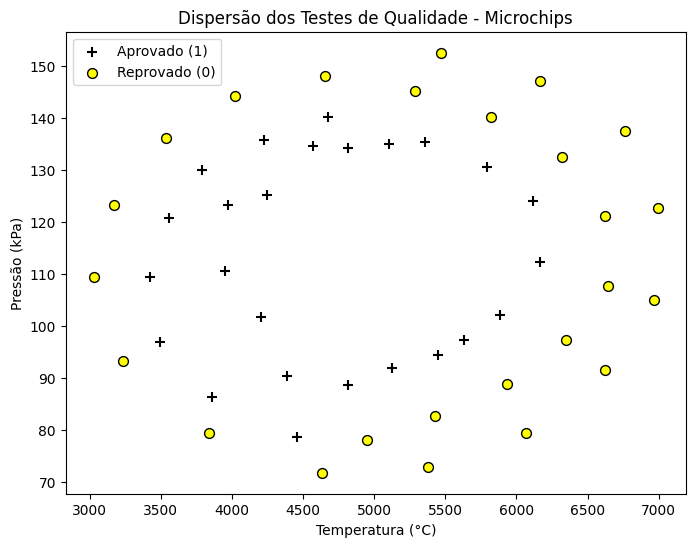

In [9]:
mascara_aprovados = (y == 1)
X_aprovados = X_real[mascara_aprovados]

mascara_reprovados = (y == 0)
X_reprovados = X_real[mascara_reprovados]

plt.figure(figsize=(8, 6))

plt.scatter(X_aprovados[:, 0], X_aprovados[:, 1], marker='+', c='black', label='Aprovado (1)', s=60)

plt.scatter(X_reprovados[:, 0], X_reprovados[:, 1], marker='o', c='yellow', edgecolors='black', label='Reprovado (0)', s=50)

plt.xlabel('Temperatura (°C)')
plt.ylabel('Pressão (kPa)')
plt.title('Dispersão dos Testes de Qualidade - Microchips')
plt.legend()

plt.show()

In [11]:
def mapear_features(X1, X2, grau=6):
    colunas_mapeadas = []
    for i in range(1, grau + 1):
        for j in range(0, i + 1):
            nova_coluna = (X1 ** (i - j)) * (X2 ** j)
            colunas_mapeadas.append(nova_coluna)
    return np.column_stack(colunas_mapeadas)                                        
      
coluna_temperatura = X_real[:, 0]
coluna_pressao = X_real[:, 1]

X_mapeado = mapear_features(coluna_temperatura, coluna_pressao, grau=6)

print(f"Formato original de X: {X_real.shape}")
print(f"Formato do novo X mapeado: {X_mapeado.shape}")
print(X_mapeado)

Formato original de X: (50, 2)
Formato do novo X mapeado: (50, 27)
[[5.10250000e+03 1.35000000e+02 2.60355062e+07 ... 8.64770967e+15
  2.28797806e+14 6.05344514e+12]
 [4.81450000e+03 1.34200000e+02 2.31794102e+07 ... 7.51817526e+15
  2.09562596e+14 5.84137510e+12]
 [4.57260000e+03 1.34600000e+02 2.09086708e+07 ... 6.86288408e+15
  2.02017276e+14 5.94662236e+12]
 ...
 [6.76160000e+03 1.37500000e+02 4.57192346e+07 ... 1.63421707e+16
  3.32324964e+14 6.75796890e+12]
 [6.16240000e+03 1.47000000e+02 3.79751738e+07 ... 1.77324649e+16
  4.22996290e+14 1.00902984e+13]
 [5.47120000e+03 1.52500000e+02 2.99340294e+07 ... 1.61899145e+16
  4.51265164e+14 1.25782164e+13]]


In [15]:
def calcular_normalizacao(X_mapeado):
    media = np.mean(X_mapeado, axis = 0)
    desvio = np.std(X_mapeado, axis = 0)
    X_norm = (X_mapeado - media) / desvio 
    print(np.mean(X_norm))
    return X_norm
print(calcular_normalizacao(X_mapeado))


-4.210623619319112e-17
[[ 0.07467423  0.96430041 -0.0349237  ...  0.70760353  0.83339087
   0.81480874]
 [-0.18497442  0.92966318 -0.28943745 ...  0.4618005   0.6685547
   0.74955118]
 [-0.40306125  0.9469818  -0.49178864 ...  0.31919966  0.60389506
   0.78193755]
 ...
 [ 1.57044879  1.07254175  1.71914181 ...  2.38202956  1.72056709
   1.03160271]
 [ 1.03023535  1.48385882  1.02904948 ...  2.68457768  2.49757523
   2.05701725]
 [ 0.40707859  1.72198976  0.3124833  ...  2.34889641  2.73982541
   2.82259201]]


In [28]:
def sigmoide(z):
    return 1/(1+np.exp(-z))

print(sigmoide(-10000))

0.0


C:\Users\danil\AppData\Local\Temp\ipykernel_25180\4010348170.py:2: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-z))
